# 1

## 1 a

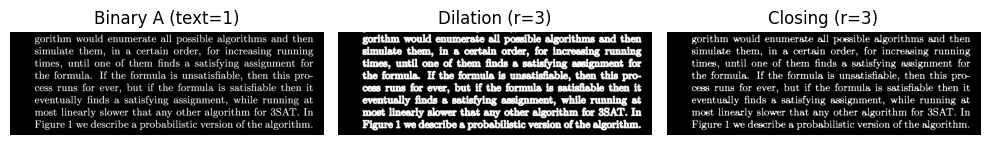

All results saved in the 'results' folder.


In [66]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# === Step 1: Load grayscale image ===
img = cv2.imread("test-images/text.png", cv2.IMREAD_GRAYSCALE)

# === Step 2: Threshold and negate (text = 1, background = 0) ===
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
binary_inv = cv2.bitwise_not(binary)
A = (binary_inv // 255).astype(np.uint8)

# === Step 3: Create disk-shaped structuring element manually ===
def make_disk(radius):
    y, x = np.ogrid[-radius:radius+1, -radius:radius+1]
    mask = x**2 + y**2 <= radius**2
    return mask.astype(np.uint8)

radius = 3  # moderately sized
se = make_disk(radius)

# === Step 4: Binary dilation ===
def binary_dilation(image, se):
    pad_y, pad_x = se.shape[0]//2, se.shape[1]//2
    padded = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0)
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+se.shape[0], j:j+se.shape[1]]
            if np.any(region & se):
                result[i, j] = 1
    return result

# === Step 5: Binary erosion ===
def binary_erosion(image, se):
    pad_y, pad_x = se.shape[0]//2, se.shape[1]//2
    padded = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0)
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+se.shape[0], j:j+se.shape[1]]
            if np.all(region[se == 1] == 1):
                result[i, j] = 1
    return result

# === Step 6: Closing = dilation followed by erosion ===
dilated = binary_dilation(A, se)
closed = binary_erosion(dilated, se)

# === Step 7: Save results ===
os.makedirs("results", exist_ok=True)

cv2.imwrite("results/binary_A.png", A * 255)
cv2.imwrite("results/dilated.png", dilated * 255)
cv2.imwrite("results/closed.png", closed * 255)

# === Step 8: Display for quick check ===
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(A, cmap='gray')
plt.title("Binary A (text=1)")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(dilated, cmap='gray')
plt.title(f"Dilation (r={radius})")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(closed, cmap='gray')
plt.title(f"Closing (r={radius})")
plt.axis('off')

plt.tight_layout()
plt.show()

print("All results saved in the 'results' folder.")


## 1 b

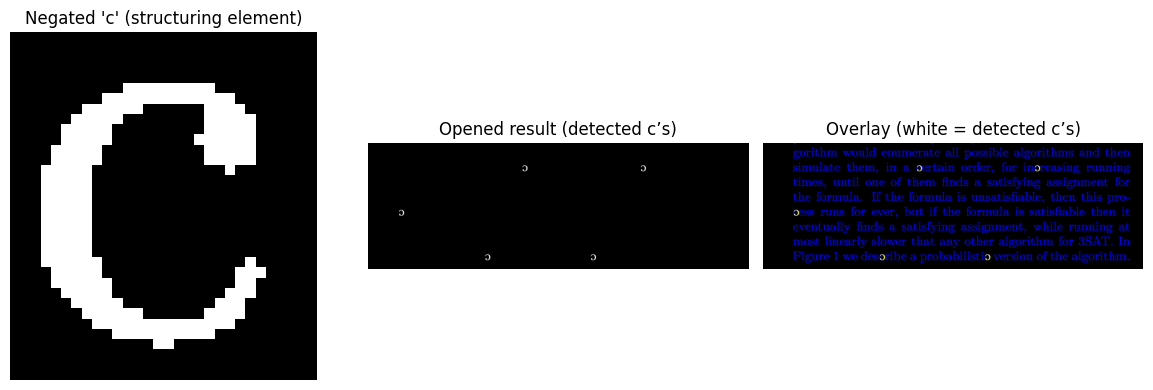

Saved results in 'results' folder:
- c_negated.png (negated structuring element)
- opening_detected_negated.png (binary detections)
- opening_overlay_negated.png (RGB overlay)


In [67]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# === Step 1: Load binary text image A ===
A = cv2.imread("results/binary_A.png", cv2.IMREAD_GRAYSCALE)
A = (A // 255).astype(np.uint8)

# === Step 2: Load and negate the cropped 'c' image ===
B = cv2.imread("test-images/c.png", cv2.IMREAD_GRAYSCALE)
# Threshold to binary
_, B = cv2.threshold(B, 128, 1, cv2.THRESH_BINARY)
# Negate so that text becomes white (1) and background black (0)
B = 1 - B



# Save the negated structuring element for record
os.makedirs("results", exist_ok=True)
cv2.imwrite("results/c_negated.png", B * 255)

# === Step 3: Manual erosion and dilation (same as before) ===
def binary_dilation(image, se):
    pad_y, pad_x = se.shape[0]//2, se.shape[1]//2
    padded = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0)
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+se.shape[0], j:j+se.shape[1]]
            if np.any(region & se):
                result[i, j] = 1
    return result

def binary_erosion(image, se):
    pad_y, pad_x = se.shape[0]//2, se.shape[1]//2
    padded = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0)
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+se.shape[0], j:j+se.shape[1]]
            if np.all(region[se == 1] == 1):
                result[i, j] = 1
    return result

# === Step 4: Opening (erosion followed by dilation) ===
eroded = binary_erosion(A, B)
opened = binary_dilation(eroded, B)

# === Step 5: Create RGB overlay ===
R = (A * 255).astype(np.uint8)
G = (opened * 255).astype(np.uint8)
Bch = (opened * 255).astype(np.uint8)
overlay = cv2.merge((R, G, Bch))

# === Step 6: Save results ===
cv2.imwrite("results/opening_detected_negated.png", opened * 255)
cv2.imwrite("results/opening_overlay_negated.png", overlay)

# === Step 7: Display results ===
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(B, cmap='gray')
plt.title("Negated 'c' (structuring element)")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(opened, cmap='gray')
plt.title("Opened result (detected c’s)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Overlay (white = detected c’s)")
plt.axis('off')

plt.tight_layout()
plt.show()

print("Saved results in 'results' folder:")
print("- c_negated.png (negated structuring element)")
print("- opening_detected_negated.png (binary detections)")
print("- opening_overlay_negated.png (RGB overlay)")


## 1 c

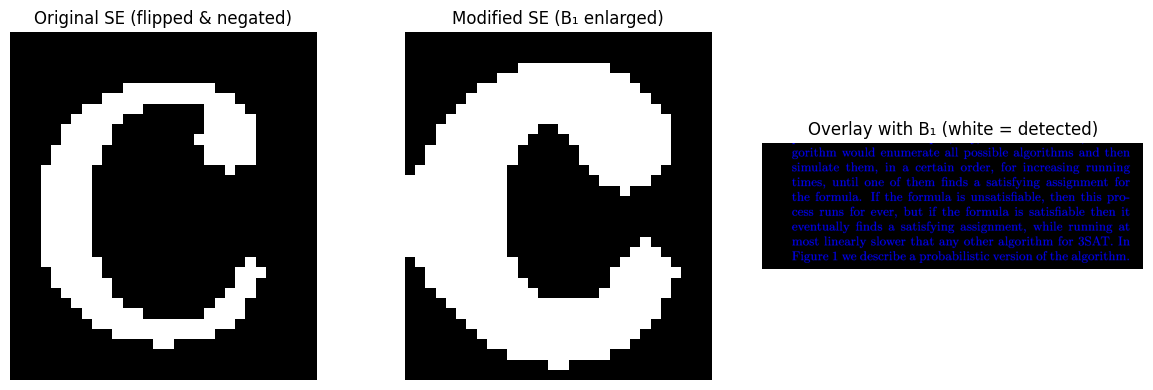

Saved fixed results in 'results' folder:
- B1_fixed.png
- opening_detected_B1_fixed.png
- opening_overlay_B1_fixed.png


In [68]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# === Step 1: Load binary image A ===
A = cv2.imread("results/binary_A.png", cv2.IMREAD_GRAYSCALE)
A = (A // 255).astype(np.uint8)

# === Step 2: Load c image and prepare structuring element ===
B = cv2.imread("test-images/c.png", cv2.IMREAD_GRAYSCALE)
_, B = cv2.threshold(B, 128, 1, cv2.THRESH_BINARY)
B = 1 - B  # make text = 1

# === Step 3: Flip for correct orientation ===
#B = np.flipud(np.fliplr(B))

# === Step 4: Enlarge slightly to allow variation ===
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
B1 = cv2.dilate(B, kernel, iterations=2)
B1 = cv2.morphologyEx(B1, cv2.MORPH_CLOSE, kernel)

# Save B1 for reference
os.makedirs("results", exist_ok=True)
cv2.imwrite("results/B1_fixed.png", B1 * 255)

# === Step 5: Manual erosion and dilation ===
def binary_dilation(image, se):
    pad_y, pad_x = se.shape[0]//2, se.shape[1]//2
    padded = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0)
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+se.shape[0], j:j+se.shape[1]]
            if np.any(region & se):
                result[i, j] = 1
    return result

def binary_erosion(image, se):
    pad_y, pad_x = se.shape[0]//2, se.shape[1]//2
    padded = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0)
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+se.shape[0], j:j+se.shape[1]]
            if np.all(region[se == 1] == 1):
                result[i, j] = 1
    return result

# === Step 6: Perform opening ===
eroded_B1 = binary_erosion(A, B1)
opened_B1 = binary_dilation(eroded_B1, B1)

# === Step 7: Overlay result ===
R = (A * 255).astype(np.uint8)
G = (opened_B1 * 255).astype(np.uint8)
Bch = (opened_B1 * 255).astype(np.uint8)
overlay_B1 = cv2.merge((R, G, Bch))

# Save results
cv2.imwrite("results/opening_detected_B1_fixed.png", opened_B1 * 255)
cv2.imwrite("results/opening_overlay_B1_fixed.png", overlay_B1)

# === Step 8: Display for inspection ===
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(B, cmap='gray')
plt.title("Original SE (flipped & negated)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(B1, cmap='gray')
plt.title("Modified SE (B₁ enlarged)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(overlay_B1, cv2.COLOR_BGR2RGB))
plt.title("Overlay with B₁ (white = detected)")
plt.axis('off')

plt.tight_layout()
plt.show()

print("Saved fixed results in 'results' folder:")
print("- B1_fixed.png")
print("- opening_detected_B1_fixed.png")
print("- opening_overlay_B1_fixed.png")


## 1 d

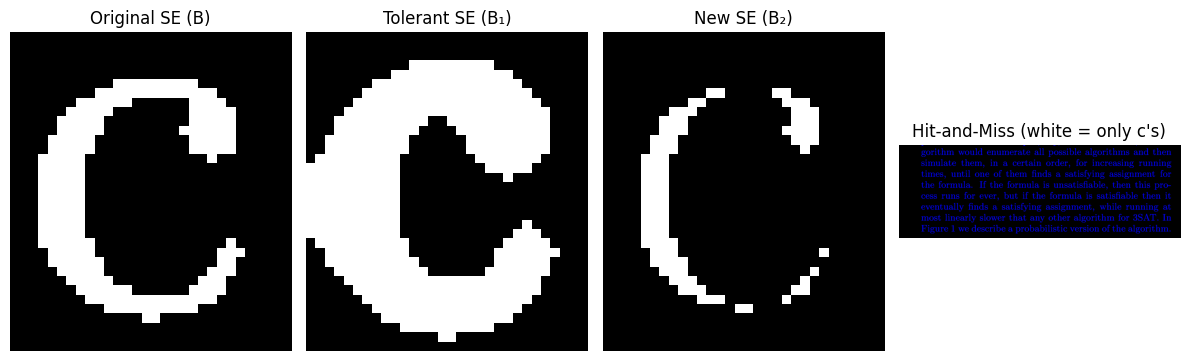

Saved results in 'results' folder:
- B2.png (constructed structuring element)
- hitmiss_detected.png (binary detections of only 'c')
- hitmiss_overlay.png (RGB overlay)


In [69]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# === Step 1: Load binary text image A ===
A = cv2.imread("results/binary_A.png", cv2.IMREAD_GRAYSCALE)
A = (A // 255).astype(np.uint8)

# === Step 2: Load structuring elements B (original) and B1 (from previous part) ===
B = cv2.imread("test-images/c.png", cv2.IMREAD_GRAYSCALE)
_, B = cv2.threshold(B, 128, 1, cv2.THRESH_BINARY)
B = 1 - B  # ensure text=1, background=0
#B = np.flipud(np.fliplr(B))  # correct orientation

B1 = cv2.imread("results/B1_fixed.png", cv2.IMREAD_GRAYSCALE)
B1 = (B1 // 255).astype(np.uint8)

# === Step 3: Construct B2 ===
# B2 is designed to remove 'e' by filling the gap in 'c' slightly
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
B2 = cv2.morphologyEx(B, cv2.MORPH_CLOSE, kernel)  # fills the open gap a bit
B2 = cv2.erode(B2, kernel, iterations=1)           # reduces to match shape inside 'c'

os.makedirs("results", exist_ok=True)
cv2.imwrite("results/B2.png", B2 * 255)

# === Step 4: Define binary erosion (for re-use) ===
def binary_erosion(image, se):
    pad_y, pad_x = se.shape[0]//2, se.shape[1]//2
    padded = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='constant', constant_values=0)
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+se.shape[0], j:j+se.shape[1]]
            if np.all(region[se == 1] == 1):
                result[i, j] = 1
    return result

# === Step 5: Hit-and-Miss transform ===
# It detects where pattern B1 (foreground) fits and B2 (background) fits simultaneously.
A_neg = 1 - A
hit = binary_erosion(A, B1)
miss = binary_erosion(A_neg, B2)
hit_miss = hit & miss

# === Step 6: Overlay result ===
R = (A * 255).astype(np.uint8)
G = (hit_miss * 255).astype(np.uint8)
Bch = (hit_miss * 255).astype(np.uint8)
overlay_hitmiss = cv2.merge((R, G, Bch))

cv2.imwrite("results/hitmiss_detected.png", hit_miss * 255)
cv2.imwrite("results/hitmiss_overlay.png", overlay_hitmiss)

# === Step 7: Display results ===
plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.imshow(B, cmap='gray')
plt.title("Original SE (B)")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(B1, cmap='gray')
plt.title("Tolerant SE (B₁)")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(B2, cmap='gray')
plt.title("New SE (B₂)")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(cv2.cvtColor(overlay_hitmiss, cv2.COLOR_BGR2RGB))
plt.title("Hit-and-Miss (white = only c's)")
plt.axis('off')

plt.tight_layout()
plt.show()

print("Saved results in 'results' folder:")
print("- B2.png (constructed structuring element)")
print("- hitmiss_detected.png (binary detections of only 'c')")
print("- hitmiss_overlay.png (RGB overlay)")


# 2

# 2 a

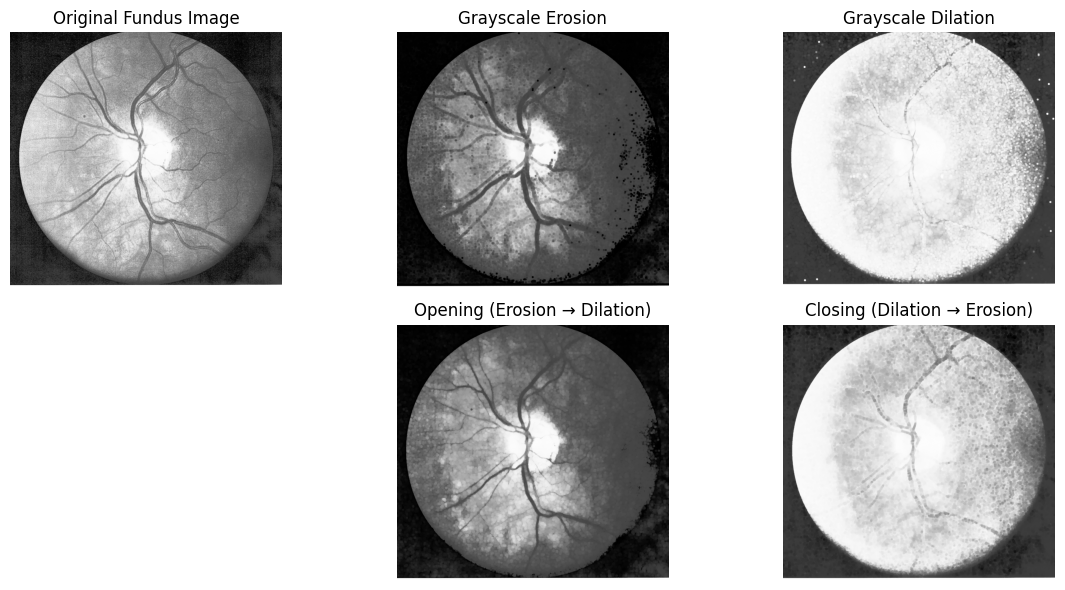

Saved all results in the 'results' folder:
- fundus_erosion.png
- fundus_dilation.png
- fundus_opening.png
- fundus_closing.png


In [70]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# === Step 1: Load the fundus image in grayscale ===
img = cv2.imread("test-images/fundus.png", cv2.IMREAD_GRAYSCALE)

# Normalize for better contrast
img = cv2.equalizeHist(img)

# === Step 2: Create a flat disk-shaped structuring element ===
def create_disk(radius):
    y, x = np.ogrid[-radius:radius+1, -radius:radius+1]
    mask = x**2 + y**2 <= radius**2
    return mask.astype(np.uint8)

radius = 5  # moderately sized disk
SE = create_disk(radius)

# === Step 3: Implement grayscale erosion and dilation ===
def grayscale_erosion(image, se):
    pad_y, pad_x = se.shape[0]//2, se.shape[1]//2
    padded = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='edge')
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+se.shape[0], j:j+se.shape[1]]
            result[i, j] = np.min(region[se == 1])
    return result

def grayscale_dilation(image, se):
    pad_y, pad_x = se.shape[0]//2, se.shape[1]//2
    padded = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='edge')
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+se.shape[0], j:j+se.shape[1]]
            result[i, j] = np.max(region[se == 1])
    return result

# === Step 4: Perform all four basic operations ===
erosion = grayscale_erosion(img, SE)
dilation = grayscale_dilation(img, SE)
opening = grayscale_dilation(erosion, SE)
closing = grayscale_erosion(dilation, SE)

# === Step 5: Save results ===
os.makedirs("results", exist_ok=True)
cv2.imwrite("results/fundus_erosion.png", erosion)
cv2.imwrite("results/fundus_dilation.png", dilation)
cv2.imwrite("results/fundus_opening.png", opening)
cv2.imwrite("results/fundus_closing.png", closing)

# === Step 6: Display results ===
plt.figure(figsize=(12, 6))
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Fundus Image")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(erosion, cmap='gray')
plt.title("Grayscale Erosion")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(dilation, cmap='gray')
plt.title("Grayscale Dilation")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(opening, cmap='gray')
plt.title("Opening (Erosion → Dilation)")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(closing, cmap='gray')
plt.title("Closing (Dilation → Erosion)")
plt.axis('off')

plt.tight_layout()
plt.show()

print("Saved all results in the 'results' folder:")
print("- fundus_erosion.png")
print("- fundus_dilation.png")
print("- fundus_opening.png")
print("- fundus_closing.png")


## 2 b

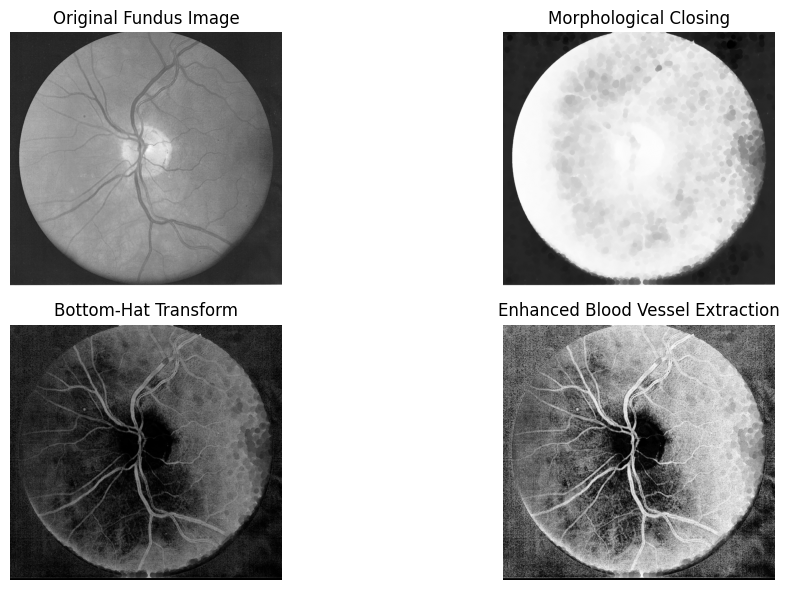

Saved results in 'results' folder:
- fundus_bottom_hat.png (raw transform)
- fundus_vessels_enhanced.png (contrast-enhanced vessels)


In [71]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# === Step 1: Load the fundus image ===
img = cv2.imread("test-images/fundus.png", cv2.IMREAD_GRAYSCALE)

# Contrast normalization for better vessel visibility
img_eq = cv2.equalizeHist(img)

# === Step 2: Create a disk-shaped structuring element ===
def create_disk(radius):
    y, x = np.ogrid[-radius:radius+1, -radius:radius+1]
    mask = x**2 + y**2 <= radius**2
    return mask.astype(np.uint8)

radius = 12  # moderately large radius to suppress background but retain vessels
SE = create_disk(radius)

# === Step 3: Implement grayscale erosion and dilation ===
def grayscale_erosion(image, se):
    pad_y, pad_x = se.shape[0]//2, se.shape[1]//2
    padded = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='edge')
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+se.shape[0], j:j+se.shape[1]]
            result[i, j] = np.min(region[se == 1])
    return result

def grayscale_dilation(image, se):
    pad_y, pad_x = se.shape[0]//2, se.shape[1]//2
    padded = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='edge')
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+se.shape[0], j:j+se.shape[1]]
            result[i, j] = np.max(region[se == 1])
    return result

# === Step 4: Compute morphological closing ===
dilated = grayscale_dilation(img_eq, SE)
closed = grayscale_erosion(dilated, SE)

# === Step 5: Compute bottom-hat transform ===
bottom_hat = cv2.subtract(closed, img_eq)

# === Step 6: Enhance contrast of the resulting vessels ===
vessels = cv2.normalize(bottom_hat, None, 0, 255, cv2.NORM_MINMAX)
vessels = cv2.equalizeHist(vessels)

# === Step 7: Save results ===
os.makedirs("results", exist_ok=True)
cv2.imwrite("results/fundus_bottom_hat.png", bottom_hat)
cv2.imwrite("results/fundus_vessels_enhanced.png", vessels)

# === Step 8: Display results ===
plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Fundus Image")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(closed, cmap='gray')
plt.title("Morphological Closing")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(bottom_hat, cmap='gray')
plt.title("Bottom-Hat Transform")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(vessels, cmap='gray')
plt.title("Enhanced Blood Vessel Extraction")
plt.axis('off')

plt.tight_layout()
plt.show()

print("Saved results in 'results' folder:")
print("- fundus_bottom_hat.png (raw transform)")
print("- fundus_vessels_enhanced.png (contrast-enhanced vessels)")


## 2 c

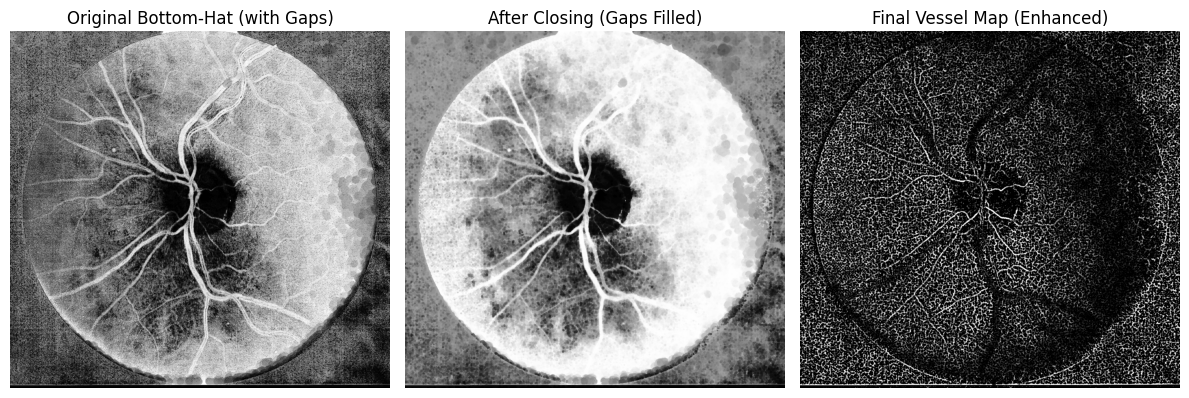

Saved results in 'results' folder:
- fundus_vessels_closed.png (gap-filled image)
- fundus_vessels_fixed.png (final enhanced vessels)


In [72]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# === Step 1: Load the bottom-hat result (from 2b) ===
bottom_hat = cv2.imread("results/fundus_vessels_enhanced.png", cv2.IMREAD_GRAYSCALE)

# === Step 2: Create a small disk-shaped SE to close thin dark gaps ===
def create_disk(radius):
    y, x = np.ogrid[-radius:radius+1, -radius:radius+1]
    mask = x**2 + y**2 <= radius**2
    return mask.astype(np.uint8)

radius_small = 3  # smaller radius to fix central gaps without losing structure
SE_small = create_disk(radius_small)

# === Step 3: Implement grayscale erosion and dilation ===
def grayscale_erosion(image, se):
    pad_y, pad_x = se.shape[0]//2, se.shape[1]//2
    padded = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='edge')
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+se.shape[0], j:j+se.shape[1]]
            result[i, j] = np.min(region[se == 1])
    return result

def grayscale_dilation(image, se):
    pad_y, pad_x = se.shape[0]//2, se.shape[1]//2
    padded = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='edge')
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+se.shape[0], j:j+se.shape[1]]
            result[i, j] = np.max(region[se == 1])
    return result

# === Step 4: Perform morphological closing to fill bright gaps ===
dilated = grayscale_dilation(bottom_hat, SE_small)
closed = grayscale_erosion(dilated, SE_small)

# === Step 5: Optional top-hat correction (to remove slight background bias) ===
# This helps restore vessel contrast if closing brightened the image too much.
opened = grayscale_dilation(grayscale_erosion(closed, SE_small), SE_small)
corrected = cv2.subtract(closed, opened)

# === Step 6: Contrast stretching for visualization ===
vessels_fixed = cv2.normalize(corrected, None, 0, 255, cv2.NORM_MINMAX)
vessels_fixed = cv2.equalizeHist(vessels_fixed)

# === Step 7: Save results ===
os.makedirs("results", exist_ok=True)
cv2.imwrite("results/fundus_vessels_closed.png", closed)
cv2.imwrite("results/fundus_vessels_fixed.png", vessels_fixed)

# === Step 8: Display results ===
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(bottom_hat, cmap='gray')
plt.title("Original Bottom-Hat (with Gaps)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(closed, cmap='gray')
plt.title("After Closing (Gaps Filled)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(vessels_fixed, cmap='gray')
plt.title("Final Vessel Map (Enhanced)")
plt.axis('off')

plt.tight_layout()
plt.show()

print("Saved results in 'results' folder:")
print("- fundus_vessels_closed.png (gap-filled image)")
print("- fundus_vessels_fixed.png (final enhanced vessels)")


## 2 d

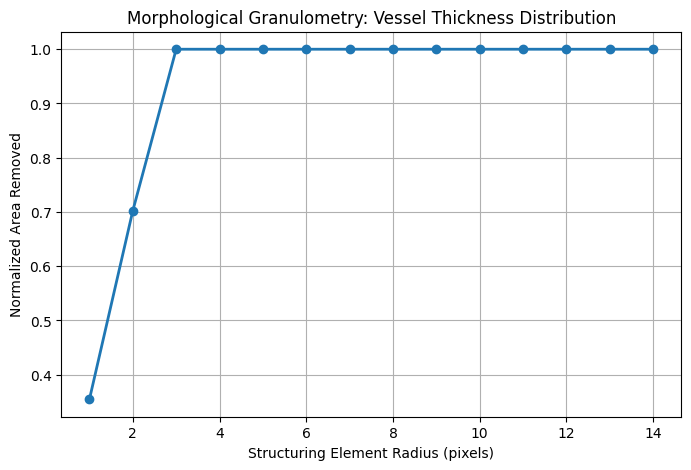

Saved results in 'results' folder:
- fundus_granulometry_curve.png (thickness graph)
- fundus_granulometry_data.txt (numerical data)


<Figure size 640x480 with 0 Axes>

In [73]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# === Step 1: Load the cleaned vessel image (from 2c) ===
img = cv2.imread("results/fundus_vessels_fixed.png", cv2.IMREAD_GRAYSCALE)

# Normalize the image
img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)

# === Step 2: Create disk-shaped structuring element generator ===
def create_disk(radius):
    y, x = np.ogrid[-radius:radius+1, -radius:radius+1]
    mask = x**2 + y**2 <= radius**2
    return mask.astype(np.uint8)

# === Step 3: Implement grayscale erosion and dilation ===
def grayscale_erosion(image, se):
    pad_y, pad_x = se.shape[0]//2, se.shape[1]//2
    padded = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='edge')
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+se.shape[0], j:j+se.shape[1]]
            result[i, j] = np.min(region[se == 1])
    return result

def grayscale_dilation(image, se):
    pad_y, pad_x = se.shape[0]//2, se.shape[1]//2
    padded = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='edge')
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+se.shape[0], j:j+se.shape[1]]
            result[i, j] = np.max(region[se == 1])
    return result

# === Step 4: Granulometry procedure ===
# Measure how much of the image is removed by successive openings
radii = list(range(1, 15))  # test multiple SE sizes (1–14 pixels)
area_original = np.sum(img)
area_opened = []
diff = []

for r in radii:
    SE = create_disk(r)
    eroded = grayscale_erosion(img, SE)
    opened = grayscale_dilation(eroded, SE)
    area = np.sum(opened)
    area_opened.append(area)
    diff.append(area_original - area)

# Normalize to get a size distribution
diff_norm = np.array(diff) / np.max(diff)

# === Step 5: Plot granulometry curve ===
plt.figure(figsize=(8, 5))
plt.plot(radii, diff_norm, 'o-', linewidth=2)
plt.title("Morphological Granulometry: Vessel Thickness Distribution")
plt.xlabel("Structuring Element Radius (pixels)")
plt.ylabel("Normalized Area Removed")
plt.grid(True)
plt.show()

# === Step 6: Save plot and results ===
os.makedirs("results", exist_ok=True)
plt.savefig("results/fundus_granulometry_curve.png", dpi=300)

np.savetxt("results/fundus_granulometry_data.txt",
           np.column_stack((radii, diff_norm)),
           header="Radius\tNormalized Area Removed", fmt="%.4f")

print("Saved results in 'results' folder:")
print("- fundus_granulometry_curve.png (thickness graph)")
print("- fundus_granulometry_data.txt (numerical data)")


# 3

## 3 a

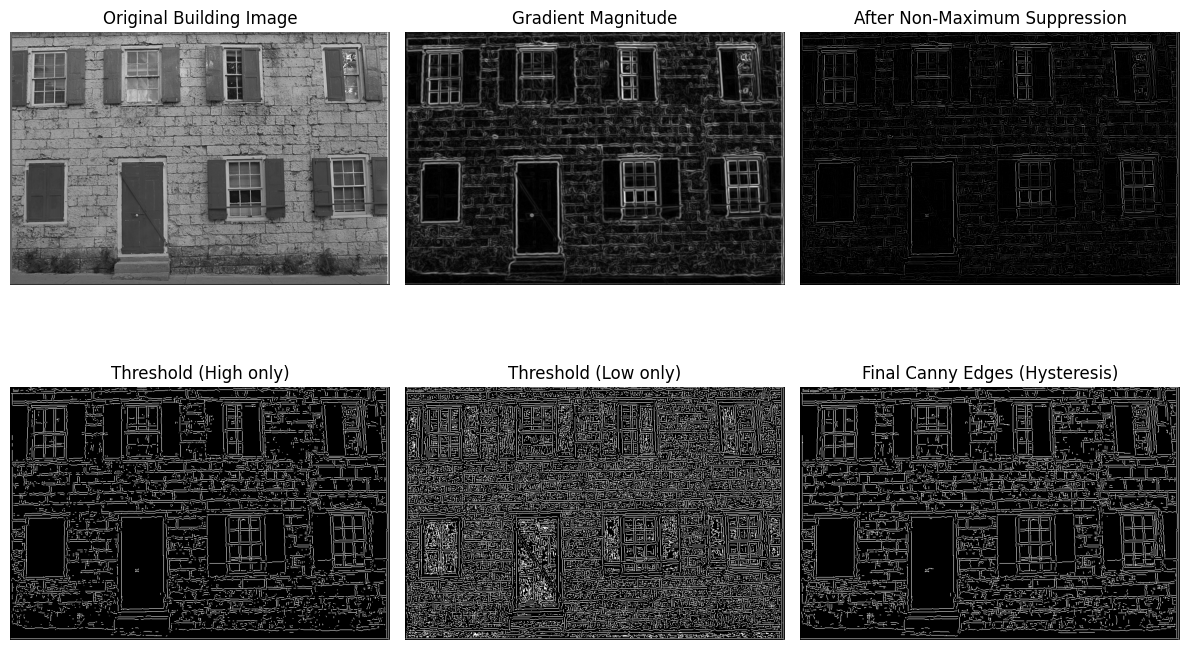

Saved intermediate results in 'results' folder:
- gradient_magnitude.png
- non_max_suppression.png
- threshold_high.png
- threshold_low.png
- canny_final_edges.png


In [74]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# === Step 1: Load the image ===
img = cv2.imread("test-images/kodak/kodim01.png", cv2.IMREAD_GRAYSCALE)

# === Step 2: Apply Gaussian blur to reduce noise ===
# Manually tune Gaussian kernel size and sigma for best edge clarity
gaussian_width = 5
sigma = 1.6
smoothed = cv2.GaussianBlur(img, (gaussian_width, gaussian_width), sigma)

# === Step 3: Compute gradient using Sobel filters ===
Gx = cv2.Sobel(smoothed, cv2.CV_64F, 1, 0, ksize=3)
Gy = cv2.Sobel(smoothed, cv2.CV_64F, 0, 1, ksize=3)

# Gradient magnitude and direction
gradient_magnitude = np.hypot(Gx, Gy)
gradient_magnitude = gradient_magnitude / gradient_magnitude.max() * 255
gradient_direction = np.arctan2(Gy, Gx)

# === Step 4: Non-Maximum Suppression ===
def non_max_suppression(grad_mag, grad_dir):
    M, N = grad_mag.shape
    Z = np.zeros((M, N), dtype=np.float32)
    angle = grad_dir * 180. / np.pi
    angle[angle < 0] += 180

    for i in range(1, M-1):
        for j in range(1, N-1):
            q = 255
            r = 255
            # Check pixel direction
            if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
                q = grad_mag[i, j+1]
                r = grad_mag[i, j-1]
            elif (22.5 <= angle[i,j] < 67.5):
                q = grad_mag[i+1, j-1]
                r = grad_mag[i-1, j+1]
            elif (67.5 <= angle[i,j] < 112.5):
                q = grad_mag[i+1, j]
                r = grad_mag[i-1, j]
            elif (112.5 <= angle[i,j] < 157.5):
                q = grad_mag[i-1, j-1]
                r = grad_mag[i+1, j+1]

            if (grad_mag[i,j] >= q) and (grad_mag[i,j] >= r):
                Z[i,j] = grad_mag[i,j]
            else:
                Z[i,j] = 0
    return Z

nms = non_max_suppression(gradient_magnitude, gradient_direction)

# === Step 5: Double thresholding ===
high_threshold_ratio = 0.15
low_threshold_ratio = 0.05
high_threshold = nms.max() * high_threshold_ratio
low_threshold = high_threshold * low_threshold_ratio

strong = 255
weak = 50

M, N = nms.shape
res = np.zeros((M,N), dtype=np.uint8)

strong_i, strong_j = np.where(nms >= high_threshold)
weak_i, weak_j = np.where((nms <= high_threshold) & (nms >= low_threshold))

res[strong_i, strong_j] = strong
res[weak_i, weak_j] = weak

# === Step 6: Hysteresis ===
def hysteresis(img):
    M, N = img.shape
    for i in range(1, M-1):
        for j in range(1, N-1):
            if img[i,j] == weak:
                if 255 in [img[i+1,j-1], img[i+1,j], img[i+1,j+1], img[i,j-1], img[i,j+1], img[i-1,j-1], img[i-1,j], img[i-1,j+1]]:
                    img[i,j] = strong
                else:
                    img[i,j] = 0
    return img

final_edges = hysteresis(res.copy())

# === Step 7: Save and display results ===
os.makedirs("results", exist_ok=True)
cv2.imwrite("results/gradient_magnitude.png", gradient_magnitude)
cv2.imwrite("results/non_max_suppression.png", nms)
cv2.imwrite("results/threshold_high.png", (nms >= high_threshold).astype(np.uint8) * 255)
cv2.imwrite("results/threshold_low.png", (nms >= low_threshold).astype(np.uint8) * 255)
cv2.imwrite("results/canny_final_edges.png", final_edges)

# === Step 8: Show results ===
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Building Image")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title("Gradient Magnitude")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(nms, cmap='gray')
plt.title("After Non-Maximum Suppression")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow((nms >= high_threshold).astype(np.uint8)*255, cmap='gray')
plt.title("Threshold (High only)")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow((nms >= low_threshold).astype(np.uint8)*255, cmap='gray')
plt.title("Threshold (Low only)")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(final_edges, cmap='gray')
plt.title("Final Canny Edges (Hysteresis)")
plt.axis('off')

plt.tight_layout()
plt.show()

print("Saved intermediate results in 'results' folder:")
print("- gradient_magnitude.png")
print("- non_max_suppression.png")
print("- threshold_high.png")
print("- threshold_low.png")
print("- canny_final_edges.png")


## 3 b

Loaded edge image with shape: (512, 768)

=== Hough Transform Report ===
Image size: 768 × 512
ρ bin width (Δρ): 1.0 pixels
θ bin width (Δθ): 1.00 degrees
ρ range: [-924.0, 924.0]
Number of ρ bins: 1849
Number of θ bins: 180
Accumulator array size: (1849, 180)
Saved result as: results/hough_transform_scaled.png
Saved plot with colorbar as: results/hough_transform_scaled_with_colorbar.png


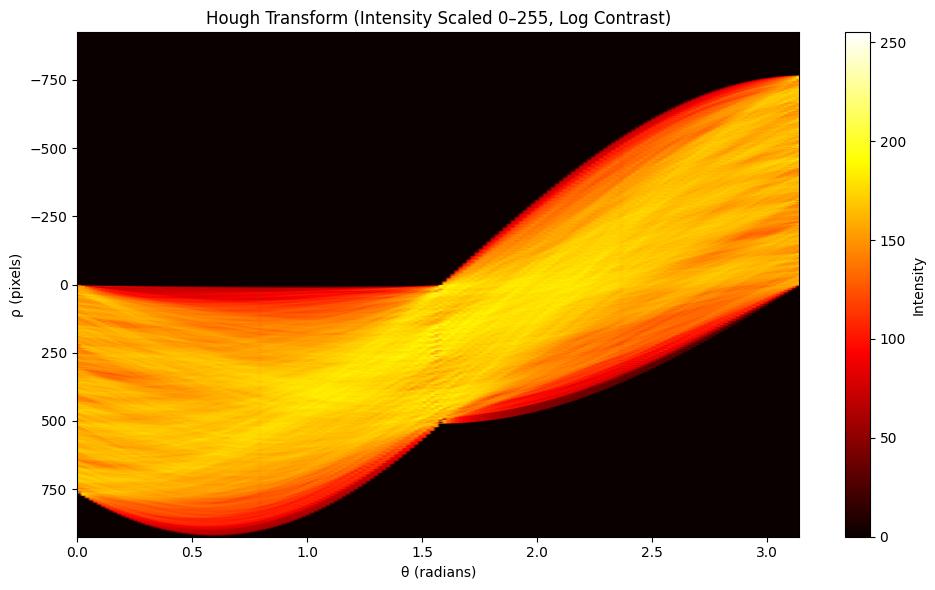


Detected 3 strong line candidates.
Saved detected line overlay as: results/hough_lines_overlay.png


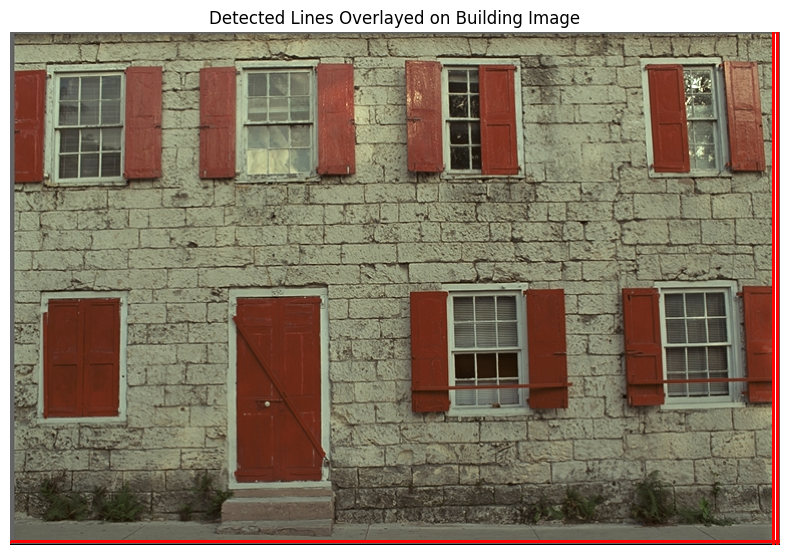

In [75]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# === Step 1 – Load the Canny edge image from part (a) ===
edges = cv2.imread("results/canny_final_edges.png", cv2.IMREAD_GRAYSCALE)
if edges is None:
    raise FileNotFoundError("Could not find 'results/canny_final_edges.png' — run part (a) first.")

# Convert to binary edges
_, edges = cv2.threshold(edges, 127, 255, cv2.THRESH_BINARY)
print(f"Loaded edge image with shape: {edges.shape}")

# === Step 2 – Set ρ and θ resolutions ===
rho_res = 1.0                   # ρ bin width = 1 pixel
theta_res = np.pi / 180.0       # θ bin width = 1 degree (π/180)

height, width = edges.shape
diag_len = int(np.ceil(np.sqrt(height ** 2 + width ** 2)))  # maximum possible ρ

# ρ ranges from –diag_len to +diag_len
rhos = np.arange(-diag_len, diag_len + 1, rho_res)
thetas = np.arange(0, np.pi, theta_res)

# === Step 3 – Create the accumulator array ===
accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.uint64)

# === Step 4 – Perform the Hough transform ===
y_idxs, x_idxs = np.nonzero(edges)
cos_t = np.cos(thetas)
sin_t = np.sin(thetas)

for i in range(len(x_idxs)):
    x = x_idxs[i]
    y = y_idxs[i]
    rho_values = x * cos_t + y * sin_t
    rho_indices = np.round(rho_values + diag_len).astype(int)
    accumulator[rho_indices, np.arange(len(thetas))] += 1

# === Step 5 – Logarithmic normalization ===
acc_log = np.log1p(accumulator.astype(np.float64))
acc_norm = (acc_log / acc_log.max() * 255).astype(np.uint8)

# === Step 6 – Save results ===
os.makedirs("results", exist_ok=True)
cv2.imwrite("results/hough_transform_scaled.png", acc_norm)

print("\n=== Hough Transform Report ===")
print(f"Image size: {width} × {height}")
print(f"ρ bin width (Δρ): {rho_res} pixels")
print(f"θ bin width (Δθ): {np.degrees(theta_res):.2f} degrees")
print(f"ρ range: [{rhos[0]}, {rhos[-1]}]")
print(f"Number of ρ bins: {len(rhos)}")
print(f"Number of θ bins: {len(thetas)}")
print(f"Accumulator array size: {accumulator.shape}")
print("Saved result as: results/hough_transform_scaled.png")

# === NEW STEP – Save Hough Transform with COLORBAR ===
plt.figure(figsize=(10, 6))
plt.imshow(acc_norm, cmap='hot', extent=[0, np.pi, rhos[-1], rhos[0]], aspect='auto', vmin=0, vmax=255)
plt.title("Hough Transform (Intensity Scaled 0–255, Log Contrast)")
plt.xlabel("θ (radians)")
plt.ylabel("ρ (pixels)")
cbar = plt.colorbar(label='Intensity')
plt.tight_layout()
plt.savefig("results/hough_transform_scaled_with_colorbar.png", dpi=300)
plt.close()
print("Saved plot with colorbar as: results/hough_transform_scaled_with_colorbar.png")

# === Step 7 – Visualize the Hough Transform ===
plt.figure(figsize=(10, 6))
plt.imshow(acc_norm, cmap='hot', extent=[0, np.pi, rhos[-1], rhos[0]], aspect='auto', vmin=0, vmax=255)
plt.title("Hough Transform (Intensity Scaled 0–255, Log Contrast)")
plt.xlabel("θ (radians)")
plt.ylabel("ρ (pixels)")
plt.colorbar(label='Intensity')
plt.tight_layout()
plt.show()

# === Step 8 – Draw strongest lines ===
img_color = cv2.imread("test-images/kodak/kodim01.png")
if img_color is None:
    img_color = cv2.imread("building.png")
if img_color is None:
    raise FileNotFoundError("Could not find the original building image for line overlay.")

threshold = 0.5 * accumulator.max()
indices = np.argwhere(accumulator > threshold)

print(f"\nDetected {len(indices)} strong line candidates.")

for rho_idx, theta_idx in indices:
    rho = rhos[rho_idx]
    theta = thetas[theta_idx]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 1000 * (-b))
    y1 = int(y0 + 1000 * (a))
    x2 = int(x0 - 1000 * (-b))
    y2 = int(y0 - 1000 * (a))
    cv2.line(img_color, (x1, y1), (x2, y2), (0, 0, 255), 2)

cv2.imwrite("results/hough_lines_overlay.png", img_color)
print("Saved detected line overlay as: results/hough_lines_overlay.png")

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.title("Detected Lines Overlayed on Building Image")
plt.axis('off')
plt.tight_layout()
plt.show()


## 3 c

Selected top 20 lines from Hough space.
Detected 6 intersection points within the image.


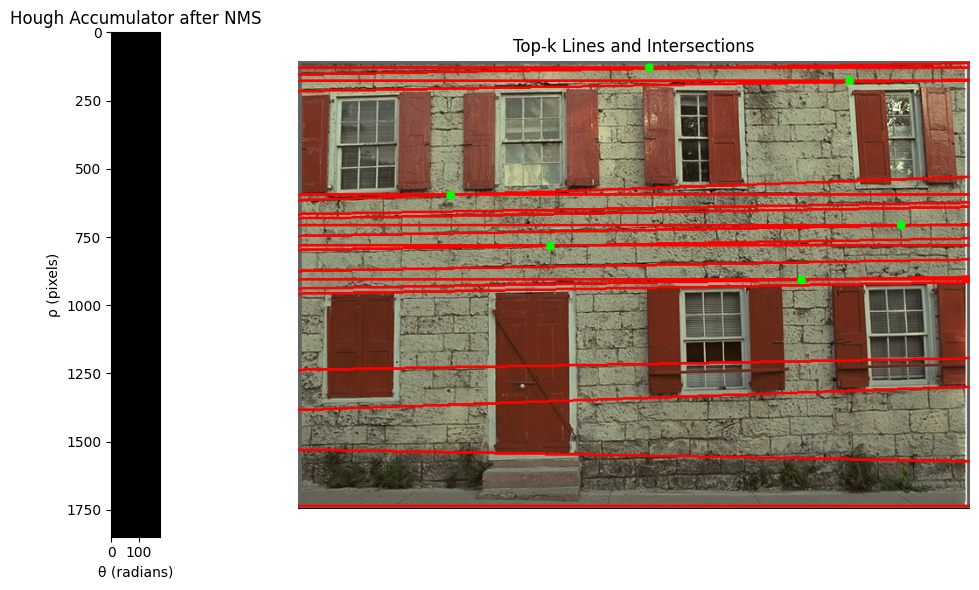

In [76]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# === Step 1: Load data from previous step ===
accumulator = np.load("results/hough_accumulator.npy") if os.path.exists("results/hough_accumulator.npy") else None
if accumulator is None:
    # Fallback: recompute quickly from edges
    edges = cv2.imread("results/canny_final_edges.png", cv2.IMREAD_GRAYSCALE)
    edges = cv2.threshold(edges, 127, 255, cv2.THRESH_BINARY)[1]
    rho_res = 1
    theta_res = np.pi / 180
    height, width = edges.shape
    diag_len = int(np.ceil(np.sqrt(height ** 2 + width ** 2)))
    rhos = np.arange(-diag_len, diag_len + 1, rho_res)
    thetas = np.arange(0, np.pi, theta_res)
    accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.uint64)
    y_idxs, x_idxs = np.nonzero(edges)
    for i in range(len(x_idxs)):
        x = x_idxs[i]
        y = y_idxs[i]
        for t_idx in range(len(thetas)):
            rho = int(round(x * np.cos(thetas[t_idx]) + y * np.sin(thetas[t_idx])) + diag_len)
            accumulator[rho, t_idx] += 1
else:
    # if loaded, rhos/thetas must match
    rho_res = 1
    theta_res = np.pi / 180
    height, width = cv2.imread("results/canny_final_edges.png", cv2.IMREAD_GRAYSCALE).shape
    diag_len = int(np.ceil(np.sqrt(height ** 2 + width ** 2)))
    rhos = np.arange(-diag_len, diag_len + 1, rho_res)
    thetas = np.arange(0, np.pi, theta_res)

# === Step 2: Non-maximum suppression in Hough space ===
acc_copy = accumulator.copy()
window_size = 9  # suppress nearby peaks
half_win = window_size // 2

def nms_hough(acc):
    acc_suppressed = np.zeros_like(acc)
    for i in range(half_win, acc.shape[0] - half_win):
        for j in range(half_win, acc.shape[1] - half_win):
            local_patch = acc[i - half_win:i + half_win + 1, j - half_win:j + half_win + 1]
            if acc[i, j] == np.max(local_patch):
                acc_suppressed[i, j] = acc[i, j]
    return acc_suppressed

acc_nms = nms_hough(acc_copy)

# === Step 3: Select top k lines ===
k = 20  # choose how many top lines to visualize
indices = np.argsort(acc_nms.ravel())[::-1][:k]
rho_idx, theta_idx = np.unravel_index(indices, acc_nms.shape)
lines = [(rhos[r], thetas[t]) for r, t in zip(rho_idx, theta_idx)]

print(f"Selected top {k} lines from Hough space.")

# === Step 4: Draw lines on original image ===
img_original = cv2.imread("test-images/kodak/kodim01.png")
if img_original is None:
    img_original = cv2.imread("building.png")

img_lines = img_original.copy()

for (rho, theta) in lines:
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a * rho
    y0 = b * rho
    x1 = int(x0 + 2000 * (-b))
    y1 = int(y0 + 2000 * (a))
    x2 = int(x0 - 2000 * (-b))
    y2 = int(y0 - 2000 * (a))
    cv2.line(img_lines, (x1, y1), (x2, y2), (0, 0, 255), 2)

# === Step 5: Compute intersection points inside image ===
intersections = []
for i in range(len(lines)):
    for j in range(i + 1, len(lines)):
        rho1, theta1 = lines[i]
        rho2, theta2 = lines[j]
        det = np.cos(theta1) * np.sin(theta2) - np.sin(theta1) * np.cos(theta2)
        if abs(det) < 1e-6:
            continue
        x = (np.sin(theta2) * rho1 - np.sin(theta1) * rho2) / det
        y = (-np.cos(theta2) * rho1 + np.cos(theta1) * rho2) / det
        if 0 <= x < img_lines.shape[1] and 0 <= y < img_lines.shape[0]:
            intersections.append((int(x), int(y)))
            cv2.circle(img_lines, (int(x), int(y)), 5, (0, 255, 0), -1)

print(f"Detected {len(intersections)} intersection points within the image.")

# === Step 6: Save and show results ===
os.makedirs("results", exist_ok=True)
cv2.imwrite("results/hough_lines_topk.png", img_lines)
acc_display = (acc_nms / acc_nms.max() * 255).astype(np.uint8)
cv2.imwrite("results/hough_accumulator_nms.png", acc_display)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(acc_display, cmap='gray')
plt.title("Hough Accumulator after NMS")
plt.xlabel("θ (radians)")
plt.ylabel("ρ (pixels)")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_lines, cv2.COLOR_BGR2RGB))
plt.title("Top-k Lines and Intersections")
plt.axis('off')

plt.tight_layout()
plt.show()


# 4

## 4 a

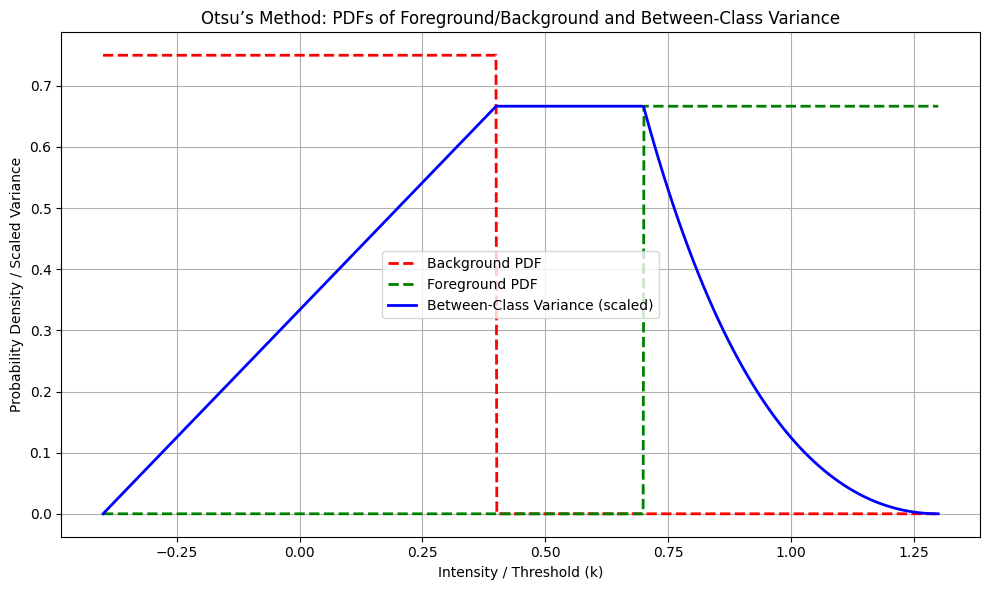

Otsu’s method fails when p is very unbalanced (foreground too small)
or when the gap between distributions is large, causing σ_b² to peak incorrectly.


In [77]:
import numpy as np
import matplotlib.pyplot as plt
import os

# === Parameters (you can modify these) ===
p = 0.4         # proportion of foreground pixels
a = 0.3         # foreground intensity half-width
b = 0.4         # background intensity half-width

# === Define intensity ranges ===
k_values = np.linspace(-b, 1 + a, 500)

# === Compute means of the uniform distributions ===
mu_f = 1.0      # mean of foreground [1 - a, 1 + a]
mu_b = 0.0      # mean of background [-b, b]

# === Between-class variance as function of threshold ===
sigma_b2 = []

for k in k_values:
    # Probability of being below threshold for each region
    w_b = (1 - p) * ((k + b) / (2 * b)) if -b <= k <= b else (1 - p) * (1 if k > b else 0)
    w_f = p * ((k - (1 - a)) / (2 * a)) if (1 - a) <= k <= (1 + a) else p * (1 if k > (1 + a) else 0)

    w_total = w_b + w_f
    if w_total == 0 or w_total == 1:
        sigma_b2.append(0)
        continue

    # Means of each class (for uniform regions)
    if -b <= k <= b:
        mu_b_k = (k ** 2 - (-b) ** 2) / (2 * (k + b))  
    elif k < -b:
        mu_b_k = -b
    else:
        mu_b_k = b

    if (1 - a) <= k <= (1 + a):
        mu_f_k = ((k ** 2 - (1 - a) ** 2) / (2 * (k - (1 - a))))  
    elif k < (1 - a):
        mu_f_k = 1 - a
    else:
        mu_f_k = 1 + a

    # Weighted means and total mean
    mu1 = (w_b * mu_b + w_f * mu_f) / (w_b + w_f + 1e-8)
    muT = p * mu_f + (1 - p) * mu_b

    # Between-class variance
    sigma_b2_val = (w_b + w_f) * (mu1 - muT) ** 2
    sigma_b2.append(sigma_b2_val)

sigma_b2 = np.array(sigma_b2)

# === Plot the PDFs of Foreground and Background ===
x = np.linspace(-b, 1 + a, 1000)
pdf_bg = np.where((-b <= x) & (x <= b), (1 - p) / (2 * b), 0)
pdf_fg = np.where(((1 - a) <= x) & (x <= (1 + a)), p / (2 * a), 0)

plt.figure(figsize=(10, 6))

# Plot PDFs
plt.plot(x, pdf_bg, 'r--', linewidth=2, label='Background PDF')
plt.plot(x, pdf_fg, 'g--', linewidth=2, label='Foreground PDF')

# Plot between-class variance
plt.plot(k_values, sigma_b2 / sigma_b2.max() * pdf_fg.max(), 'b-', linewidth=2, label='Between-Class Variance (scaled)')

# Labels and legend
plt.title("Otsu’s Method: PDFs of Foreground/Background and Between-Class Variance")
plt.xlabel("Intensity / Threshold (k)")
plt.ylabel("Probability Density / Scaled Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()

# === NEW: Save figure ===
os.makedirs("results", exist_ok=True)
plt.savefig("results/otsu_variance_plot.png", dpi=300)

# Show graph
plt.show()

# === Analytical note ===
print("Otsu’s method fails when p is very unbalanced (foreground too small)")
print("or when the gap between distributions is large, causing σ_b² to peak incorrectly.")


## 4 b

In [78]:
import numpy as np

# === Parameters (same model as part a) ===
p = 0.4      # proportion of foreground
a = 0.3      # foreground half width (uniform in [1-a, 1+a])
b = 0.4      # background half width (uniform in [-b, b])

N = 200000   # number of samples (large for good statistics)

# === Generate synthetic intensities ===
# Background: uniform in [-b, b]
bg = np.random.uniform(-b, b, int((1 - p) * N))

# Foreground: uniform in [1 - a, 1 + a]
fg = np.random.uniform(1 - a, 1 + a, int(p * N))

# Combined dataset
X = np.hstack([bg, fg])

# === Step 1: Initialize k-means cluster centers EXACTLY at true means ===
mu0 = 0.0  # background class mean
mu1 = 1.0  # foreground class mean

# === Step 2: One iteration of assignment ===
dist0 = np.abs(X - mu0)
dist1 = np.abs(X - mu1)

labels = (dist1 < dist0).astype(int)

# === Step 3: Compute updated means after 1 iteration ===
new_mu0 = X[labels == 0].mean()
new_mu1 = X[labels == 1].mean()

print("=== K-means One Iteration Result ===")
print(f"Initial means: μ0 = 0.0, μ1 = 1.0")
print(f"Updated μ0 = {new_mu0:.4f}")
print(f"Updated μ1 = {new_mu1:.4f}")

# === Check if clustering agrees with ground truth ===
true_labels = np.hstack([np.zeros(len(bg)), np.ones(len(fg))])
accuracy = (labels == true_labels).mean()

print(f"\nClustering accuracy after ONE iteration = {accuracy*100:.2f}%")

# Decision threshold used by k-means = midpoint
threshold = (mu0 + mu1) / 2
print(f"\nK-means threshold after 1 iteration = {threshold:.3f}")
print(f"Otsu threshold from theory should be anywhere in the gap [{b}, {1-a}] if it exists")


=== K-means One Iteration Result ===
Initial means: μ0 = 0.0, μ1 = 1.0
Updated μ0 = 0.0003
Updated μ1 = 1.0004

Clustering accuracy after ONE iteration = 100.00%

K-means threshold after 1 iteration = 0.500
Otsu threshold from theory should be anywhere in the gap [0.4, 0.7] if it exists


# 5 

## 5 a

/var/folders/dd/vfnx3x1x2bvbyk9k4dgpt0jh0000gn/T/ipykernel_35674/1468371055.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  pts = plt.ginput(k)


Initial K-means centroids:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
Iteration 1, centroid shift = 127.0140
Iteration 2, centroid shift = 55.6826
Iteration 3, centroid shift = 37.6064
Iteration 4, centroid shift = 20.7633
Iteration 5, centroid shift = 19.5814
Iteration 6, centroid shift = 16.1047
Iteration 7, centroid shift = 15.9776
Iteration 8, centroid shift = 18.3242
Iteration 9, centroid shift = 18.9555
Iteration 10, centroid shift = 20.7241
Iteration 11, centroid shift = 22.9551
Iteration 12, centroid shift = 23.1169
Iteration 13, centroid shift = 16.0671
Iteration 14, centroid shift = 11.6619
Iteration 15, centroid shift = 10.6398
Iteration 16, centroid shift = 7.5425
Iteration 17, centroid shift = 5.0708
Iteration 18, centroid shift = 4.1472
Iteration 19, centroid shift = 3.6395
Iteration 20, centroid shift = 3.8301
Saved:
 - results/kmeans_scratch_segmented.png
 - results/kmeans_scratch_boundaries.png


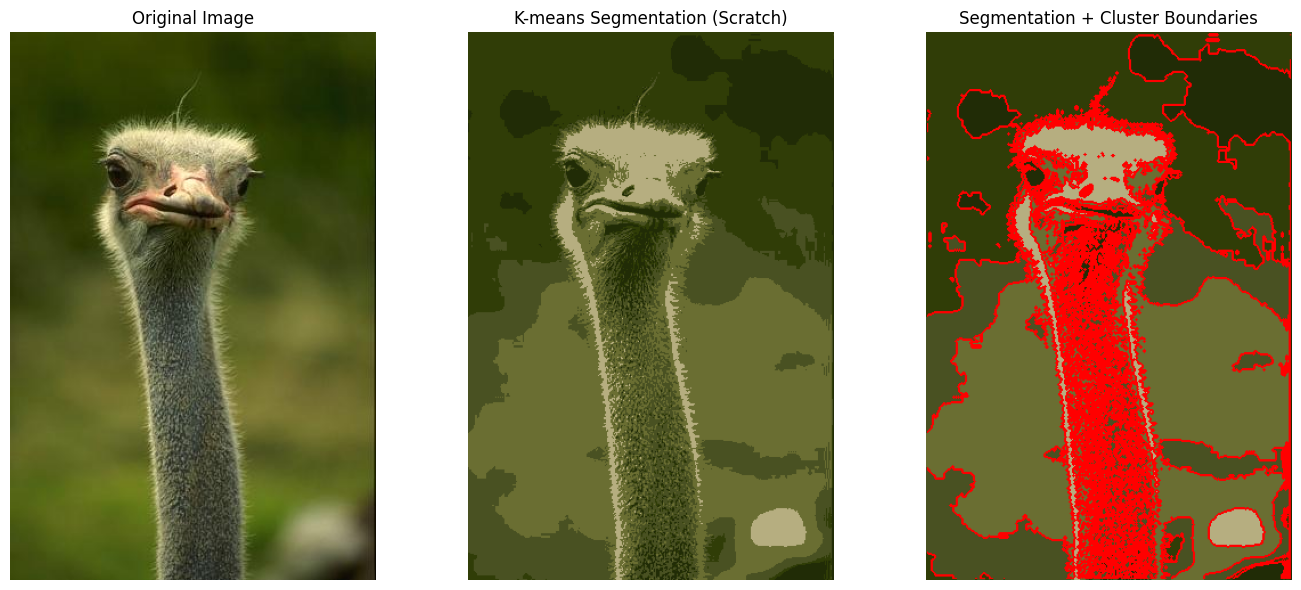

In [79]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
#  LOAD IMAGE
# ============================================================
img = cv2.imread("test-images/training.png")
if img is None:
    raise FileNotFoundError("Could not find test-images/training.png")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, _ = img_rgb.shape
pixels = img_rgb.reshape((-1, 3)).astype(np.float32)

# ============================================================
#  PARAMETERS
# ============================================================
k = 5    # number of clusters

# ============================================================
#  MANUAL INITIALIZATION BY CLICKING K POINTS
# ============================================================
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title(f"CLICK {k} INITIAL MEANS")
pts = plt.ginput(k)
plt.close()

init_means = np.zeros((k, 3), dtype=np.float32)
for i, (x, y) in enumerate(pts):
    init_means[i] = img_rgb[int(y), int(x)]

print("Initial K-means centroids:")
print(init_means)

# ============================================================
#  K-MEANS FROM SCRATCH
# ============================================================

def compute_distances(data, centers):
    """
    Compute squared Euclidean distance between each pixel and each centroid.
    Returns a (num_pixels x k) matrix.
    """
    return np.sum((data[:, None, :] - centers[None, :, :]) ** 2, axis=2)

def kmeans_from_scratch(data, init_centers, max_iter=20, tol=1e-4):
    centers = init_centers.copy()
    n = data.shape[0]
    labels = np.zeros(n, dtype=int)

    for it in range(max_iter):
        # ---- Step 1: Assign each pixel to nearest centroid ----
        distances = compute_distances(data, centers)
        new_labels = np.argmin(distances, axis=1)

        # ---- Step 2: Update centroids ----
        new_centers = np.zeros_like(centers)
        for c in range(k):
            cluster_points = data[new_labels == c]
            if len(cluster_points) > 0:
                new_centers[c] = np.mean(cluster_points, axis=0)
            else:
                new_centers[c] = centers[c]  # unchanged if empty

        # ---- Check convergence ----
        shift = np.linalg.norm(new_centers - centers)
        print(f"Iteration {it+1}, centroid shift = {shift:.4f}")

        centers = new_centers
        labels = new_labels

        if shift < tol:
            print("Converged.")
            break

    return labels, centers

# Run K-means
labels, centers = kmeans_from_scratch(pixels, init_means)

# Convert centers back to uint8 for display
centers_uint8 = np.clip(centers, 0, 255).astype(np.uint8)

# ============================================================
#  CREATE SEGMENTED IMAGE
# ============================================================
segmented = centers_uint8[labels].reshape((h, w, 3))

# ============================================================
#  DETECT BOUNDARIES BETWEEN CLUSTERS
# ============================================================
label_img = labels.reshape((h, w))
boundary = np.zeros((h, w), dtype=np.uint8)

for i in range(1, h-1):
    for j in range(1, w-1):
        c = label_img[i, j]
        if (label_img[i+1, j] != c or
            label_img[i-1, j] != c or
            label_img[i, j+1] != c or
            label_img[i, j-1] != c):
            boundary[i, j] = 255

seg_with_boundary = segmented.copy()
seg_with_boundary[boundary == 255] = [255, 0, 0]   # red boundaries

# ============================================================
#  SAVE RESULTS
# ============================================================
os.makedirs("results", exist_ok=True)
cv2.imwrite("results/kmeans_scratch_segmented.png", cv2.cvtColor(segmented, cv2.COLOR_RGB2BGR))
cv2.imwrite("results/kmeans_scratch_boundaries.png", cv2.cvtColor(seg_with_boundary, cv2.COLOR_RGB2BGR))

print("Saved:")
print(" - results/kmeans_scratch_segmented.png")
print(" - results/kmeans_scratch_boundaries.png")

# ============================================================
#  DISPLAY RESULTS
# ============================================================
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(segmented)
plt.title("K-means Segmentation (Scratch)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(seg_with_boundary)
plt.title("Segmentation + Cluster Boundaries")
plt.axis("off")

plt.tight_layout()
plt.show()


## 5 b

Superpixels: 686
Iteration 1: Center shift = 4.5690
Iteration 2: Center shift = 2.1813
Iteration 3: Center shift = 1.4586
Iteration 4: Center shift = 1.1586
Iteration 5: Center shift = 0.9726
Iteration 6: Center shift = 0.7887
Iteration 7: Center shift = 0.6984
Iteration 8: Center shift = 0.6169
Iteration 9: Center shift = 0.5276
Iteration 10: Center shift = 0.4878
Saved:
  results/slic_segmented.png
  results/slic_boundaries.png


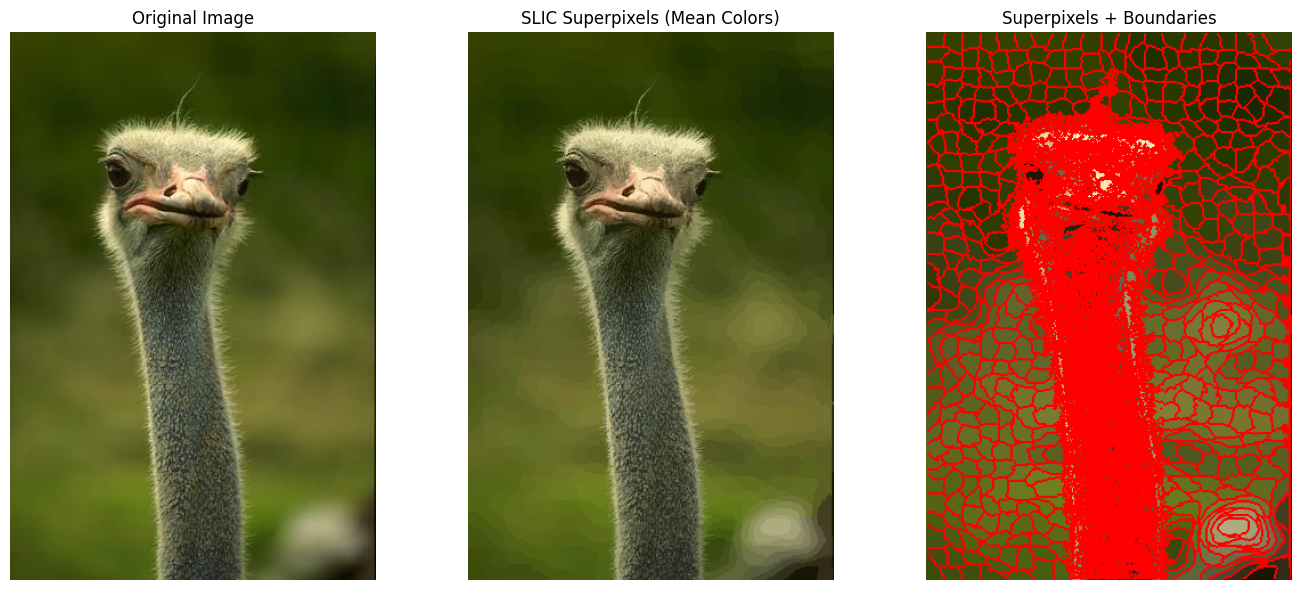

In [80]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ===========================================================
# LOAD IMAGE
# ===========================================================
img = cv2.imread("test-images/training.png")
if img is None:
    raise FileNotFoundError("Could not find test-images/training.png")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
H, W, _ = img_rgb.shape

# ===========================================================
# PARAMETERS
# ===========================================================
s = 15      # requested superpixel spacing (between 10 and 20)
m = 10      # compactness (10–20 recommended)
S = s       # spacing for cluster grid

N = H * W
K = int((H * W) / (S * S))
print("Superpixels:", K)

# ===========================================================
# INITIALIZE CLUSTER CENTERS ON GRID
# ===========================================================
cluster_centers = []
for y in range(S // 2, H, S):
    for x in range(S // 2, W, S):
        cluster_centers.append([y, x, img_rgb[y, x, 0], img_rgb[y, x, 1], img_rgb[y, x, 2]])

cluster_centers = np.array(cluster_centers, dtype=np.float32)
K = cluster_centers.shape[0]

# ===========================================================
# STORAGE FOR ASSIGNMENTS
# ===========================================================
labels = -1 * np.ones((H, W), dtype=int)
distances = np.full((H, W), np.inf, dtype=np.float32)

# ===========================================================
# SLIC ITERATIONS
# ===========================================================
for itr in range(10):

    distances[:] = np.inf

    for k in range(K):
        cy, cx, r, g, b = cluster_centers[k]

        y0 = max(int(cy - 2*S), 0)
        y1 = min(int(cy + 2*S), H)
        x0 = max(int(cx - 2*S), 0)
        x1 = min(int(cx + 2*S), W)

        region = img_rgb[y0:y1, x0:x1]

        Y, X = np.mgrid[y0:y1, x0:x1]

        d_lab = np.sqrt(
            (region[:, :, 0] - r)**2 +
            (region[:, :, 1] - g)**2 +
            (region[:, :, 2] - b)**2
        )

        d_xy = np.sqrt((Y - cy)**2 + (X - cx)**2)

        D = d_lab + (m / S) * d_xy

        patch_distances = distances[y0:y1, x0:x1]
        patch_labels = labels[y0:y1, x0:x1]

        mask = D < patch_distances
        patch_distances[mask] = D[mask]
        patch_labels[mask] = k

        distances[y0:y1, x0:x1] = patch_distances
        labels[y0:y1, x0:x1] = patch_labels

    # ---- Recompute cluster centers ----
    new_centers = np.zeros_like(cluster_centers)
    counts = np.zeros(K)

    for y in range(H):
        for x in range(W):
            k = labels[y, x]
            counts[k] += 1
            new_centers[k, 0] += y
            new_centers[k, 1] += x
            new_centers[k, 2:] += img_rgb[y, x]

    for k in range(K):
        if counts[k] > 0:
            new_centers[k] /= counts[k]

    shift = np.mean(np.linalg.norm(new_centers - cluster_centers, axis=1))
    print(f"Iteration {itr+1}: Center shift = {shift:.4f}")

    cluster_centers = new_centers

    if shift < 0.5:
        break


# ===========================================================
# CREATE SUPERPIXEL IMAGE
# ===========================================================
segmented = np.zeros_like(img_rgb)

for k in range(K):
    mask = (labels == k)
    if np.any(mask):
        mean_color = img_rgb[mask].mean(axis=0)
        segmented[mask] = mean_color

segmented = segmented.astype(np.uint8)

# ===========================================================
# EXTRACT BOUNDARIES
# ===========================================================
boundary = np.zeros((H, W), dtype=np.uint8)

for y in range(1, H-1):
    for x in range(1, W-1):
        if (labels[y, x] != labels[y+1, x] or
            labels[y, x] != labels[y-1, x] or
            labels[y, x] != labels[y, x+1] or
            labels[y, x] != labels[y, x-1]):
            boundary[y, x] = 255

overlay = segmented.copy()
overlay[boundary == 255] = [255, 0, 0]  # red boundaries

# ===========================================================
# SAVE RESULTS
# ===========================================================
os.makedirs("results", exist_ok=True)
cv2.imwrite("results/slic_segmented.png", cv2.cvtColor(segmented, cv2.COLOR_RGB2BGR))
cv2.imwrite("results/slic_boundaries.png", cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

print("Saved:")
print("  results/slic_segmented.png")
print("  results/slic_boundaries.png")

# ===========================================================
# DISPLAY RESULTS
# ===========================================================
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb.astype(np.uint8))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(segmented)
plt.title("SLIC Superpixels (Mean Colors)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Superpixels + Boundaries")
plt.axis("off")

plt.tight_layout()
plt.show()
